### [STAGE #1] Train SWAG

In [3]:
import torch
import math

In [4]:
def train_swag(model, data_loader, lr, T, c, K):
    """
    theta_0: pretrained weights (model)
    lr (\eta): learning rate
    T: number of steps
    c: moment update frequency
    K: maximum number of columns in deviation matrix
    """
    # Initialize moments
    # 논문: \bar{\theta} <- \theta_0, \bar{\theta^2} <- \theta_0^2
    theta_bar = get_flat_weights(model) 
    theta_sq_bar = theta_bar ** 2
    
    # Deviation 행렬 D 초기화 (비어있는 상태)
    D = torch.empty((0, len(theta_bar))) 
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # for i <- 1, 2, ..., T do
    for i in range(1, T + 1):
        # \theta_i <- \theta_{i-1} - \eta \nabla L(\theta_{i-1}) (Perform SGD update)
        batch_x, batch_y = get_next_batch(data_loader)
        optimizer.zero_grad()
        loss = compute_loss(model, batch_x, batch_y)
        loss.backward()
        optimizer.step() 
        
        # if MOD(i, c) = 0 then
        if i % c == 0:
            theta_i = get_flat_weights(model)
            n = i // c  # n <- i / c
            
            # \bar{\theta} <- (n * \bar{\theta} + \theta_i) / (n + 1)
            theta_bar = (n * theta_bar + theta_i) / (n + 1)
            
            # \bar{\theta^2} <- (n * \bar{\theta^2} + \theta_i^2) / (n + 1)
            theta_sq_bar = (n * theta_sq_bar + (theta_i ** 2)) / (n + 1)
            
            # if NUM_COLS(D) = K then REMOVE_COL(D[:, 1])
            if D.size(0) == K:
                D = D[1:] # 큐처럼 가장 오래된 것(첫 번째 행) 제거
            
            # APPEND_COL(D, \theta_i - \bar{\theta})
            deviation = (theta_i - theta_bar).unsqueeze(0)
            D = torch.cat([D, deviation], dim=0)

    # return \theta_SWA = \bar{\theta}, \Sigma_diag = \bar{\theta^2} - \bar{\theta}^2, \hat{D}
    theta_swa = theta_bar
    sigma_diag = theta_sq_bar - (theta_bar ** 2)
    D_hat = D
    
    return theta_swa, sigma_diag, D_hat

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
/var/folders/09/2vv_837j5vz09b6fz7k4vhf80000gn/T/ipykernel_26253/3273870948.py:2: SyntaxWarning: invalid escape sequence '\e'
  """


### [STAGE #2] Test Bayesian Model Averaging

In [5]:
def test_bma(model, test_data, theta_swa, sigma_diag, D_hat, K, S):
    """
    S: number of samples in Bayesian model averaging
    """
    predictions_sum = 0
    
    # for i <- 1, 2, ..., S do
    for i in range(S):
        # Draw \tilde{\theta_i} ~ N(...) 수식 (1) 적용
        z_1 = torch.randn_like(theta_swa)
        z_2 = torch.randn(D_hat.size(0))
        
        # 수식 (1): \theta_SWA + 1/\sqrt{2} * \Sigma_diag^{1/2} * z_1 + 1/\sqrt{2(K-1)} * \hat{D} * z_2
        term1 = (1.0 / math.sqrt(2.0)) * torch.sqrt(sigma_diag) * z_1
        term2 = (1.0 / math.sqrt(2.0 * (K - 1))) * torch.matmul(z_2, D_hat)
        theta_tilde = theta_swa + term1 + term2
        
        # 샘플링된 파라미터를 모델에 덮어씌우기
        set_flat_weights(model, theta_tilde)
        
        # Update batch norm statistics with new sample
        update_batch_norm(model) 
        
        # p(y* | Data) += (1/S) * p(y* | \tilde{\theta_i})
        pred = compute_predictions(model, test_data)
        predictions_sum += (1.0 / S) * pred

    # return p(y* | Data)
    return predictions_sum

Simplification

In [6]:
import torch
import torch.nn as nn
from torch.nn.utils import parameters_to_vector, vector_to_parameters
import math

In [7]:
class SWAG(nn.Module):
    def __init__(self, base_model, K=20):
        super(SWAG, self).__init__()
        self.base_model = base_model
        self.K = K 
        self.n_models = 0
        
        # 1차원 벡터 크기 계산
        num_params = sum(p.numel() for p in base_model.parameters())
        
        # 논문의 theta_bar, theta_sq_bar, D 행렬을 클래스 변수로 캡슐화
        self.theta_bar = torch.zeros(num_params)
        self.theta_sq_bar = torch.zeros(num_params)
        self.D = torch.empty((0, num_params))

    def update_moments(self):
        # 1단계 코드의 "if MOD(i, c) = 0 then" 블록을 이 함수 하나로 대체
        theta_i = parameters_to_vector(self.base_model.parameters()).detach()
        n = self.n_models
        
        # 이동 평균(Moving Average) 업데이트
        self.theta_bar = (n * self.theta_bar + theta_i) / (n + 1)
        self.theta_sq_bar = (n * self.theta_sq_bar + theta_i ** 2) / (n + 1)
        
        # 편차 행렬(D) 업데이트 및 큐 길이(K) 유지
        deviation = (theta_i - self.theta_bar).unsqueeze(0)
        self.D = torch.cat([self.D, deviation], dim=0)
        if self.D.size(0) > self.K:
            self.D = self.D[1:] # 제일 오래된 것 제거
            
        self.n_models += 1

    def sample_and_apply(self, scale=0.5):
        # 1단계 코드의 Draw \tilde{\theta_i} 부분을 PyTorch 텐서 연산으로 최적화
        sigma_diag = torch.clamp(self.theta_sq_bar - self.theta_bar ** 2, min=1e-30)
        
        z_1 = torch.randn_like(self.theta_bar)
        z_2 = torch.randn(self.D.size(0))
        
        # 논문의 scale 적용 (1/sqrt(2) 대신 범용적인 scale 값 사용)
        term1 = math.sqrt(scale) * torch.sqrt(sigma_diag) * z_1
        term2 = math.sqrt(scale / (self.K - 1)) * torch.matmul(z_2, self.D)
        
        theta_tilde = self.theta_bar + term1 + term2
        
        # 계산된 파라미터를 모델에 즉시 주입 (1단계의 set_flat_weights 역할)
        vector_to_parameters(theta_tilde, self.base_model.parameters())

- Train SWAG에서는 theta_bar, D 등의 변수가 학습 루프 안에서 지저분하게 관리
- SWAG 클래스가 스스로 자신의 통계량을 기억함.

-> swag_model.update_moments()만 호출하면 됨

Pytorch=가중치가 레이어별로 나뉘어있음.
- 이를 한 줄로 펴주는 parameters_to_vector와 다시 모델에 덮어씌워주는 vector_to_parameters의 활용이 핵심.

### [STAGE #3] Bayesian Model Averaging(BMA) 및 BN 업데이트 로직 구현

가중치가 무작위로 샘플링되면서 레이어의 활성화 값(Activation) 분포가 바뀌기 때문에, 테스트 데이터 예측을 수행하기 전에 반드시 학습 데이터의 일부를 흘려보내서 BN 통계량(평균, 분산)을 새로 고쳐주어야 함.

In [8]:
import torch
import torch.nn.functional as F
from torch.optim.swa_utils import update_bn

In [9]:
def test_swag_performance(swag_model, train_loader, test_loader, num_samples=30):
    swag_model.base_model.eval()
    
    all_bma_predictions = [] # (num_samples, 데이터수, 클래스수)
    true_labels = []
    
    # 1. 정답 레이블 수집
    for _, targets in test_loader:
        true_labels.append(targets)
    true_labels = torch.cat(true_labels)

    # 2. BMA 앙상블 수행
    with torch.no_grad():
        for i in range(num_samples):
            # 2-1. SWAG 분포에서 새로운 가중치 샘플링
            swag_model.sample_and_apply(scale=0.5)
            
            # 2-2. [핵심!!] 샘플링된 가중치에 맞게 BatchNorm 통계량 재계산
            # train_loader의 데이터를 모델에 통과시켜 BN의 running_mean/var를 맞춥니다.
            update_bn(train_loader, swag_model.base_model)
            
            # 2-3. 테스트 데이터 예측
            sample_preds = []
            for inputs, _ in test_loader:
                outputs = swag_model.base_model(inputs)
                probabilities = F.softmax(outputs, dim=1)
                sample_preds.append(probabilities)
            
            all_bma_predictions.append(torch.cat(sample_preds))
            print(f"Sample {i+1}/{num_samples} 완료")

    # 3. 앙상블 결과 통합 (평균)
    all_bma_predictions = torch.stack(all_bma_predictions) # shape: (30, N, C)
    
    # 베이지안 모델 에버리징 (예측 확률의 평균)
    final_probabilities = all_bma_predictions.mean(dim=0)
    final_predictions = final_probabilities.argmax(dim=1)
    
    # 예측의 불확실성 (엔트로피로 계산)
    # 엔트로피가 높을수록 모델이 헷갈려 한다는 뜻입니다.
    entropy = -torch.sum(final_probabilities * torch.log(final_probabilities + 1e-12), dim=1)
    
    # 기본 정확도 계산
    accuracy = (final_predictions == true_labels).float().mean().item()
    print(f"SWAG Test Accuracy: {accuracy * 100:.2f}%")
    
    return final_probabilities, true_labels, entropy

Calibration Test(ECE 측정; Expected Calibration Error)

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def calculate_ece_and_plot(probabilities, labels, num_bins=10):
    """
    1. Reliability Diagram(신뢰도 다이어그램)을 그리고 ECE 값을 계산합니다.
    probabilities: BMA를 거친 최종 예측 확률 (N, num_classes)
    labels: 실제 정답 레이블 (N,)
    """
    confidences, predictions = torch.max(probabilities, dim=1)
    accuracies = predictions.eq(labels)
    
    ece = torch.zeros(1, device=probabilities.device)
    bin_boundaries = torch.linspace(0, 1, num_bins + 1)
    
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    bin_accuracies = []
    bin_confidences = []
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = confidences.gt(bin_lower.item()) * confidences.le(bin_upper.item())
        prop_in_bin = in_bin.float().mean()
        
        if prop_in_bin.item() > 0:
            accuracy_in_bin = accuracies[in_bin].float().mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            
            ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
            bin_accuracies.append(accuracy_in_bin.item())
            bin_confidences.append(avg_confidence_in_bin.item())
        else:
            bin_accuracies.append(0)
            bin_confidences.append(0)

    # ---------------- 시각화 (Reliability Diagram) ----------------
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.bar(bin_lowers.numpy(), bin_accuracies, width=1/num_bins, alpha=0.7, edgecolor='black', align='edge', label='Model Accuracy')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title(f'Reliability Diagram (ECE: {ece.item():.4f})')
    plt.legend()
    plt.show()
    
    return ece.item()

OOD(Out-of-Distribution) Detection Test

In [12]:
def plot_ood_histogram(id_entropy, ood_entropy):
    """
    2. In-Distribution과 Out-of-Distribution의 불확실성(Entropy) 분포를 비교합니다.
    """
    plt.figure(figsize=(8, 5))
    plt.hist(id_entropy.numpy(), bins=50, alpha=0.6, density=True, label='In-Distribution (MNIST)', color='blue')
    plt.hist(ood_entropy.numpy(), bins=50, alpha=0.6, density=True, label='Out-of-Distribution (FashionMNIST)', color='red')
    plt.xlabel('Predictive Entropy (Uncertainty)')
    plt.ylabel('Density')
    plt.title('OOD Detection using SWAG Predictive Entropy')
    plt.legend()
    plt.show()

Load Dataset

In [13]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [14]:
# 1. 데이터셋 준비 (MNIST는 ID, FashionMNIST는 OOD로 사용)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # MNIST 평균/표준편차
])

# In-Distribution (MNIST - 숫자)
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
id_test_loader = DataLoader(mnist_test, batch_size=128, shuffle=False)

# Out-of-Distribution (FashionMNIST - 옷, 신발 등)
fashion_test = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
ood_test_loader = DataLoader(fashion_test, batch_size=128, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [01:16<00:00, 129kB/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 62.0kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



...

Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:38<00:00, 114kB/s] 


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 5.02MB/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



Base Model Definition

In [15]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [16]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # MNIST 클래스 개수

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = x.view(-1, 64 * 7 * 7) # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 2. 모델 객체 생성
base_model = SimpleCNN()

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(base_model.parameters(), lr=0.01, momentum=0.9)

# ---------------------------------------------------------
# [Phase 1] 일반적인 사전 학습 (Normal Pre-training)
# ---------------------------------------------------------
print("기본 모델 사전 학습 중...")
for epoch in range(3): # 빠른 테스트를 위해 3 에폭
    base_model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = base_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

# ---------------------------------------------------------
# [Phase 2] SWAG 학습 (SWAG Training) - 궤적 수집
# ---------------------------------------------------------
swag_model = SWAG(base_model, K=20)
swag_model.to(device)

swag_optimizer = optim.SGD(swag_model.base_model.parameters(), lr=0.01)

print("SWAG 통계량(Moments) 수집 중...")
for epoch in range(2): # 2 에폭
    swag_model.base_model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        swag_optimizer.zero_grad()
        outputs = swag_model.base_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        swag_optimizer.step()
        
    # 매 에폭마다 현재 가중치 상태 기록
    swag_model.update_moments()

기본 모델 사전 학습 중...
SWAG 통계량(Moments) 수집 중...


--- 1. In-Distribution (MNIST) 평가 및 Calibration 측정 ---
Sample 1/30 완료
Sample 2/30 완료
Sample 3/30 완료
Sample 4/30 완료
Sample 5/30 완료
Sample 6/30 완료
Sample 7/30 완료
Sample 8/30 완료
Sample 9/30 완료
Sample 10/30 완료
Sample 11/30 완료
Sample 12/30 완료
Sample 13/30 완료
Sample 14/30 완료
Sample 15/30 완료
Sample 16/30 완료
Sample 17/30 완료
Sample 18/30 완료
Sample 19/30 완료
Sample 20/30 완료
Sample 21/30 완료
Sample 22/30 완료
Sample 23/30 완료
Sample 24/30 완료
Sample 25/30 완료
Sample 26/30 완료
Sample 27/30 완료
Sample 28/30 완료
Sample 29/30 완료
Sample 30/30 완료
SWAG Test Accuracy: 98.90%


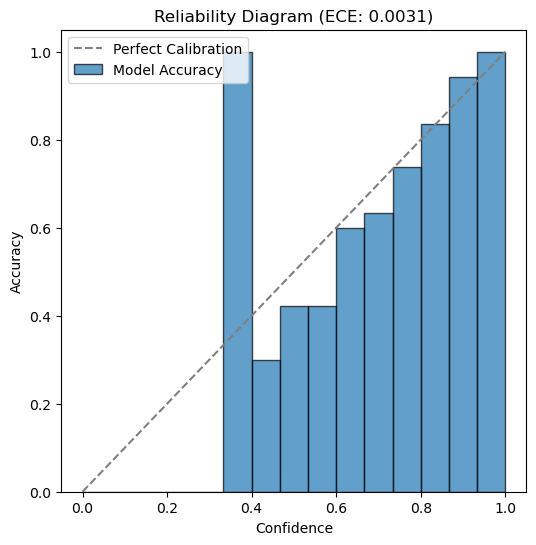

MNIST 데이터에 대한 ECE(Expected Calibration Error): 0.0031

--- 2. Out-of-Distribution (FashionMNIST) 평가 ---
Sample 1/30 완료
Sample 2/30 완료
Sample 3/30 완료
Sample 4/30 완료
Sample 5/30 완료
Sample 6/30 완료
Sample 7/30 완료
Sample 8/30 완료
Sample 9/30 완료
Sample 10/30 완료
Sample 11/30 완료
Sample 12/30 완료
Sample 13/30 완료
Sample 14/30 완료
Sample 15/30 완료
Sample 16/30 완료
Sample 17/30 완료
Sample 18/30 완료
Sample 19/30 완료
Sample 20/30 완료
Sample 21/30 완료
Sample 22/30 완료
Sample 23/30 완료
Sample 24/30 완료
Sample 25/30 완료
Sample 26/30 완료
Sample 27/30 완료
Sample 28/30 완료
Sample 29/30 완료
Sample 30/30 완료
SWAG Test Accuracy: 14.76%


In [17]:
print("--- 1. In-Distribution (MNIST) 평가 및 Calibration 측정 ---")
# id_probs: (데이터수, 10), id_labels: (데이터수,), id_entropy: (데이터수,)
id_probs, id_labels, id_entropy = test_swag_performance(
    swag_model, train_loader, id_test_loader, num_samples=30
)

# ECE 계산 및 Reliability Diagram 출력
ece_score = calculate_ece_and_plot(id_probs, id_labels, num_bins=15)
print(f"MNIST 데이터에 대한 ECE(Expected Calibration Error): {ece_score:.4f}")

print("\n--- 2. Out-of-Distribution (FashionMNIST) 평가 ---")
# OOD 데이터에 대해서도 BMA 수행 (학습 데이터 통계량 유지를 위해 train_loader는 MNIST 사용)
ood_probs, ood_labels, ood_entropy = test_swag_performance(
    swag_model, train_loader, ood_test_loader, num_samples=30
)

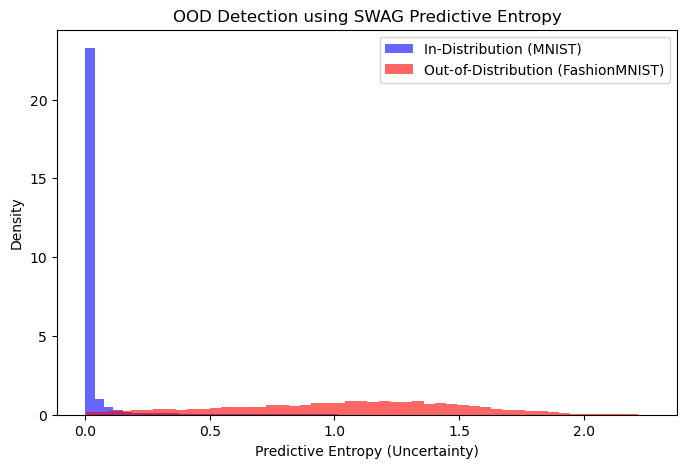

In [18]:
# ID vs OOD 엔트로피 비교 히스토그램 출력
plot_ood_histogram(id_entropy.detach().cpu(), ood_entropy.detach().cpu())

NLL(Negative Log-Likelihood)

In [19]:
nll_loss = -torch.log(id_probs[range(len(id_labels)), id_labels] + 1e-12).mean()
print(f"MNIST 데이터에 대한 NLL (Negative Log-Likelihood): {nll_loss.item():.4f}")

MNIST 데이터에 대한 NLL (Negative Log-Likelihood): 0.0292


PCA 기반 SGD 궤적 및 SWAG 분포 시각화 코드

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import multivariate_normal

In [23]:
def plot_swag_pca_trajectory(swag_model):
    """
    고차원의 가중치 궤적(D 행렬)을 2차원 PCA 공간으로 압축하여,
    SGD의 이동 경로와 SWAG가 형성한 가우시안 분포(등고선)를 시각화합니다.
    """
    print("PCA 분석 및 궤적 시각화를 준비 중입니다...")
    
    # 1. SWAG 모델에 저장된 편차 행렬 D 가져오기
    # D 행렬의 각 행은 (theta_i - theta_bar) 즉, 평균으로부터 떨어진 거리를 의미합니다.
    D_matrix = swag_model.D.cpu().numpy()
    
    if D_matrix.shape[0] < 2:
        print("궤적을 그리기에는 수집된 모델(K)의 수가 너무 적습니다.")
        return

    # 2. PCA를 사용하여 고차원 가중치 공간을 2차원으로 압축
    pca = PCA(n_components=2)
    trajectory_2d = pca.fit_transform(D_matrix)
    
    # 3. 2D 공간에서의 SWAG 가우시안 분포(평균=0, 공분산=궤적의 공분산) 세팅
    # 평균(theta_bar)은 편차 행렬의 기준점이므로 2D 공간의 원점 (0, 0)이 됩니다.
    mean_2d = np.array([0.0, 0.0])
    
    # 궤적 점들을 기반으로 2x2 공분산 행렬 계산
    cov_2d = np.cov(trajectory_2d.T)
    cov_2d = cov_2d + np.eye(2) * 1e-6
    
    # 4. 등고선을 그리기 위한 2D 그리드(격자) 생성
    x_min, x_max = trajectory_2d[:, 0].min() - 5, trajectory_2d[:, 0].max() + 5
    y_min, y_max = trajectory_2d[:, 1].min() - 5, trajectory_2d[:, 1].max() + 5
    x, y = np.mgrid[x_min:x_max:.1, y_min:y_max:.1]
    pos = np.dstack((x, y))
    
    # 가우시안 확률 밀도 함수(PDF) 계산
    rv = multivariate_normal(mean_2d, cov_2d, allow_singular=True)
    z = rv.pdf(pos)
    
    # 5. 시각화 (Plotting)
    plt.figure(figsize=(10, 8))
    
    # 배경에 SWAG 가우시안 분포의 등고선 채우기
    plt.contourf(x, y, z, levels=15, cmap='Blues', alpha=0.6)
    
    # SGD가 이동한 궤적 그리기 (선 + 점)
    plt.plot(trajectory_2d[:, 0], trajectory_2d[:, 1], 'k--', alpha=0.5, label='SGD Trajectory')
    plt.scatter(trajectory_2d[:, 0], trajectory_2d[:, 1], c='red', s=50, edgecolors='black', label='Sampled Weights (theta_i)')
    
    # SWAG 평균 위치 (원점) 찍기
    plt.scatter(0, 0, c='yellow', s=200, marker='*', edgecolors='black', label='SWAG Mean (theta_bar)')
    
    plt.title('PCA Projection of SGD Trajectory and SWAG Distribution', fontsize=14)
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

PCA 분석 및 궤적 시각화를 준비 중입니다...


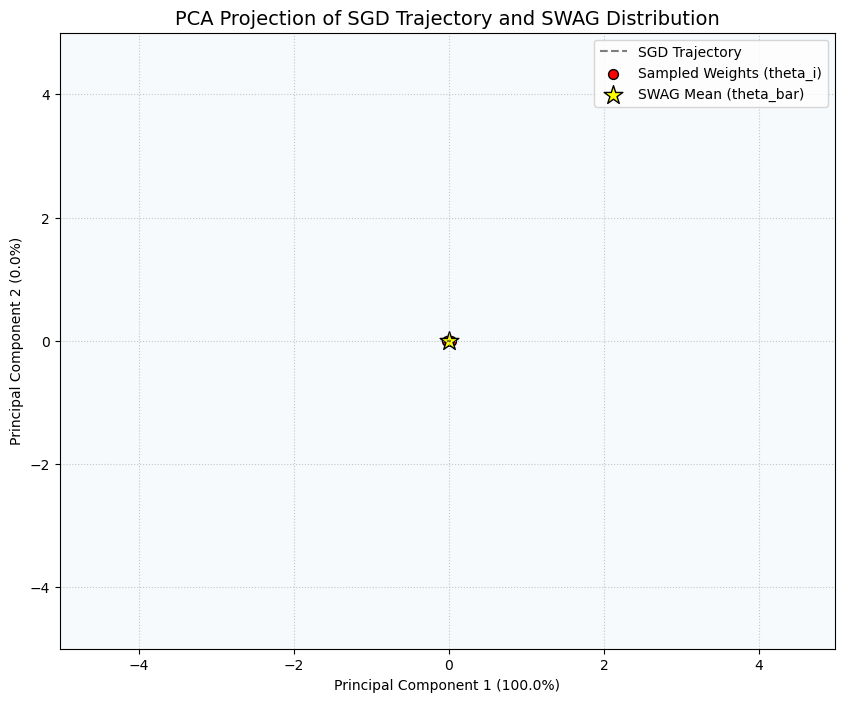

In [24]:
plot_swag_pca_trajectory(swag_model)